# Dynamic Achievement Points System - Ensemble Learning

This notebook implements an ensemble learning system for calculating dynamic achievement points using:
- Tree-Based Models: XGBoost, LightGBM, CatBoost
- Deep Learning: TabNet
- Text Features: Fast TF-IDF (instead of slow BERT)
- Meta-Learner: Ridge Regression

**Note**: BERT is disabled by default for speed. Use TF-IDF for text features instead. (ALthough neither does much)


## Step 0: Set-up (Imports/Define Configs)

In [97]:
# Import all required libraries
import pyodbc
import pandas as pd
import numpy as np
import json
import os
import warnings
from dotenv import load_dotenv
from typing import Dict, List, Tuple, Optional
import pickle
from datetime import datetime
from collections import Counter
import itertools

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
try:
    from pytorch_tabnet.tab_model import TabNetRegressor
    import torch
    TABNET_AVAILABLE = True
except ImportError:
    TABNET_AVAILABLE = False
    print("TabNet not available")

warnings.filterwarnings('ignore')
load_dotenv()

print("All libraries imported successfully")

All libraries imported successfully


In [98]:
DB_CONFIG = {
    'server': os.getenv('DB_HOST', 'localhost'),
    'database': os.getenv('DB_NAME', 'steam-games-achievements'),
    'user': os.getenv('DB_USER', 'Cursor'),
    'password': os.getenv('DB_PASSWORD', 'Completion100'),
    'driver': '{ODBC Driver 17 for SQL Server}',
    'TrustServerCertificate': 'yes'
}

# Model configuration
import multiprocessing
N_JOBS = multiprocessing.cpu_count() # Use all available CPU cores

MODEL_CONFIG = {
    'xgb': {
        'n_estimators': 2000,  
        'max_depth': 15,       
        'learning_rate': 0.005,  
        'subsample': 0.9,      
        'colsample_bytree': 0.9,
        'colsample_bylevel': 0.9,
        'colsample_bynode': 0.9, 
        'min_child_weight': 1,  
        'gamma': 0.05,        
        'reg_alpha': 0.05,      
        'reg_lambda': 0.5,      
        'max_delta_step': 0,   
        'random_state': 42,
        'n_jobs': N_JOBS,
        'tree_method': 'hist'
    },
    'lgb': {
        'n_estimators': 2000,  
        'max_depth': 15,       
        'learning_rate': 0.005,  
        'subsample': 0.9,      
        'colsample_bytree': 0.9,
        'colsample_bynode': 0.9,
        'min_child_samples': 10,  
        'min_split_gain': 0.05,  
        'reg_alpha': 0.05,      
        'reg_lambda': 0.5,      
        'num_leaves': 255,      
        'max_bin': 255,  
        'random_state': 42,
        'verbose': -1,
        'n_jobs': N_JOBS
    },
    'cat': {
        'iterations': 2000,    
        'depth': 10,           
        'learning_rate': 0.005,  
        'l2_leaf_reg': 1.0,    
        'bootstrap_type': 'Bayesian',
        'bagging_temperature': 0.5,  
        'random_strength': 0.5,  
        'od_type': 'Iter',
        'od_wait': 30,         
        'max_bin': 254,        
        'random_seed': 42,
        'verbose': False,
        'thread_count': N_JOBS
    },
    'tabnet': {
        'n_d': 32,
        'n_a': 32,
        'n_steps': 5,
        'gamma': 1.5,
        'n_independent': 2,
        'n_shared': 2,
        'lambda_sparse': 1e-3,
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': {'lr': 2e-2},
        'mask_type': 'entmax',
        'device_name': 'cpu'
    },
    'ridge': {
        'alpha': 1.0,
        'random_state': 42
    }
}
# Fast text processing settings
USE_BERT = False
USE_TFIDF = False
TFIDF_MAX_FEATURES = 100
print("Configuration loaded")

Configuration loaded


In [99]:
def get_db_connection():
    # Create database connection
    try:
        conn_str = (
            f"DRIVER={DB_CONFIG['driver']};"
            f"SERVER={DB_CONFIG['server']};"
            f"DATABASE={DB_CONFIG['database']};"
            f"UID={DB_CONFIG['user']};"
            f"PWD={DB_CONFIG['password']};"
            f"TrustServerCertificate={DB_CONFIG['TrustServerCertificate']}"
        )
        return pyodbc.connect(conn_str)
    except Exception as e:
        print(f"❌ Database connection error: {e}")
        raise

def extract_price_numeric(price_str):
    # Extract numeric price from formatted string
    if pd.isna(price_str) or price_str is None:
        return None
    if isinstance(price_str, (int, float)):
        return float(price_str)
    if isinstance(price_str, str):
        import re
        cleaned = price_str.replace(',', '').strip()
        if cleaned.lower() in ['free', 'gratis', '0']:
            return 0.0
        numbers = re.findall(r'\d+\.?\d*', cleaned)
        if numbers:
            try:
                for num_str in numbers:
                    if not num_str or num_str == '.':
                        continue
                    if num_str.startswith('.'):
                        num_str = '0' + num_str
                    if num_str.count('.') > 1:
                        parts = num_str.split('.')
                        if len(parts) > 2:
                            num_str = f"{parts[0]}.{parts[-1]}"
                    try:
                        return float(num_str)
                    except (ValueError, TypeError):
                        continue
            except Exception:
                return None
    return None

def parse_json_field(field):
    # Parse JSON field (tags, genres, categories)    
    if pd.isna(field) or field is None:
        return []
    if isinstance(field, str):
        try:
            parsed = json.loads(field)
            if isinstance(parsed, dict):
                return list(parsed.keys())
            elif isinstance(parsed, list):
                return parsed
            else:
                return [str(parsed)]
        except:
            if ',' in field:
                return [x.strip() for x in field.split(',')]
            return [field]
    return []

print("Helper functions defined")

Helper functions defined


## Step 1: Fetch Data from Database


In [ ]:
# Fetch comprehensive achievement and game data
print("Fetching comprehensive achievement and game data...")
conn = get_db_connection()
query = """
SELECT 
    a.id as achievement_id,
    a.game_id,
    a.name as achievement_name,
    a.description as achievement_description,
    a.points as current_points,
    a.is_hidden,
    a.steam_apiname,
    g.steam_appid,
    g.name as game_name,
    g.release_date,
    g.developer,
    g.publisher,
    g.genres,
    g.categories,
    g.tags,
    g.platforms,
    g.short_description,
    g.price,
    g.original_price,
    g.discount_percent,
    g.currency,
    g.steam_rating,
    g.metacritic_score,
    g.recommendations,
    g.main_story_hours,
    g.main_sides_hours,
    g.completionist_hours,
    g.all_styles_hours,
    g.score_rank,
    g.owners,
    g.peak_ccu,
    g.languages,
    
    -- Achievement statistics (check both tables)
    COALESCE(ast.global_percentage, a.global_percentage, 0) as global_percentage
    
FROM achievements a
INNER JOIN games g ON a.game_id = g.id
LEFT JOIN achievement_stats ast ON a.id = ast.achievement_id
ORDER BY a.id
"""

df = pd.read_sql(query, conn)
conn.close()
print(f"Fetched {len(df)} total achievements from database")
# Filter and report on data availability
has_global_pct = df['global_percentage'].notna() & (df['global_percentage'] > 0)
print(f"   - Achievements with global_percentage: {has_global_pct.sum()}")
has_steam_rating = df['steam_rating'].notna()
print(f"   - Games with steam_rating: {has_steam_rating.sum()}")

# Filter to records with global_percentage
df_filtered = df[has_global_pct].copy()
if len(df_filtered) == 0:
    print(f"\nNo achievements with global_percentage found.")
    print(f"Using all achievements with default rarity...")
    df_filtered = df.copy()
    df_filtered['global_percentage'] = df_filtered['global_percentage'].fillna(50.0)
print(f"Using {len(df_filtered)} achievements for training")
df = df_filtered.copy()

Fetching comprehensive achievement and game data...
Fetched 2360038 total achievements from database
   - Achievements with global_percentage: 2146731
   - Games with steam_rating: 0
Using 2146731 achievements for training


In [102]:
print("Engineering numeric features...")
# Price features
df['price_numeric'] = df['price'].apply(extract_price_numeric)
df['original_price_numeric'] = df['original_price'].apply(extract_price_numeric)
df['discount_percent'] = pd.to_numeric(df['discount_percent'], errors='coerce')
df['is_free'] = (df['price_numeric'] == 0) | (df['price'] == 'Free') | (df['price'].str.contains('Free', case=False, na=False))
df['is_free'] = df['is_free'].astype(int)

# Game popularity metrics
df['steam_rating'] = pd.to_numeric(df['steam_rating'], errors='coerce')
df['metacritic_score'] = pd.to_numeric(df['metacritic_score'], errors='coerce')
df['recommendations'] = pd.to_numeric(df['recommendations'], errors='coerce')
df['score_rank'] = pd.to_numeric(df['score_rank'], errors='coerce')
df['owners'] = pd.to_numeric(df['owners'], errors='coerce')
df['peak_ccu'] = pd.to_numeric(df['peak_ccu'], errors='coerce')

# Normalize popularity scores
df['steam_rating_norm'] = df['steam_rating'] / 100.0
df['metacritic_norm'] = df['metacritic_score'] / 100.0
df['recommendations_log'] = np.log1p(df['recommendations'].fillna(0))
df['owners_log'] = np.log1p(df['owners'].fillna(0))
df['peak_ccu_log'] = np.log1p(df['peak_ccu'].fillna(0))
df['score_rank_norm'] = 1.0 / (1.0 + df['score_rank'].fillna(1000000))

# Combined popularity score
df['popularity_score'] = (
    df['steam_rating_norm'].fillna(0) * 0.3 +
    df['metacritic_norm'].fillna(0) * 0.2 +
    (df['recommendations_log'] / np.log1p(100000)) * 0.2 +
    (df['owners_log'] / np.log1p(10000000)) * 0.15 +
    (df['peak_ccu_log'] / np.log1p(1000000)) * 0.1 +
    df['score_rank_norm'].fillna(0) * 0.05
)
print("Game popularity features created")

Engineering numeric features...
Game popularity features created


In [103]:
# Time to complete features
df['main_story_hours'] = pd.to_numeric(df['main_story_hours'], errors='coerce')
df['completionist_hours'] = pd.to_numeric(df['completionist_hours'], errors='coerce')
if 'main_sides_hours' in df.columns:
    df['main_sides_hours'] = pd.to_numeric(df['main_sides_hours'], errors='coerce')
elif 'main_plus_hours' in df.columns:
    df['main_sides_hours'] = pd.to_numeric(df['main_plus_hours'], errors='coerce')
else:
    df['main_sides_hours'] = None
df['all_styles_hours'] = pd.to_numeric(df['all_styles_hours'], errors='coerce')
df['game_time_hours'] = df['completionist_hours'].fillna(
    df['main_sides_hours'].fillna(df['main_story_hours'].fillna(0))
)

# Achievement rarity
df['global_percentage'] = pd.to_numeric(df['global_percentage'], errors='coerce').fillna(0)
df['rarity_score'] = 100 * np.exp(-df['global_percentage'] / 20)
df['rarity_score'] = df['rarity_score'].clip(1, 100)
# Achievement features
df['is_hidden'] = df['is_hidden'].astype(int)
df['achievement_name_length'] = df['achievement_name'].str.len().fillna(0)
df['achievement_desc_length'] = df['achievement_description'].str.len().fillna(0)
# Game age
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['game_age_days'] = (datetime.now() - df['release_date']).dt.days
df['game_age_days'] = df['game_age_days'].fillna(0)
df['game_age_years'] = df['game_age_days'] / 365.25

# Age-standardized rarity: adjust global_percentage so very new games
max_age_years = max(df['game_age_years'].max(), 1e-3)
age_norm = (df['game_age_years'] / max_age_years).clip(0, 1)
# age_factor in [0.5, 1.0]: newer games (closer to 0 years) get 0.5, older get ~1.0
age_factor = 0.5 + 0.5 * age_norm
# Effective percentage after accounting for exposure over time
df['global_percentage_age_adj'] = df['global_percentage'] / age_factor
# Recompute an age-adjusted rarity score
df['rarity_score_age_adj'] = 100 * np.exp(-df['global_percentage_age_adj'] / 20)
df['rarity_score_age_adj'] = df['rarity_score_age_adj'].clip(1, 100)
print("Time, rarity, and achievement features created (with age-standardized rarity)")

# Unlisted / removed flags
if 'is_unlisted' in df.columns:
    df['is_unlisted'] = df['is_unlisted'].fillna(0).astype(int)
else:
    df['is_unlisted'] = 0

if 'is_removed' in df.columns:
    df['is_removed'] = df['is_removed'].fillna(0).astype(int)
else:
    df['is_removed'] = 0

Time, rarity, and achievement features created (with age-standardized rarity)


In [104]:
# Categorical features
df['genres_list'] = df['genres'].apply(parse_json_field)
df['tags_list'] = df['tags'].apply(parse_json_field)
df['categories_list'] = df['categories'].apply(parse_json_field)

if 'languages' in df.columns:
    df['languages_list'] = df['languages'].apply(parse_json_field)
    df['num_languages'] = df['languages_list'].str.len()
else:
    df['num_languages'] = 0

# Basic counts
df['num_genres'] = df['genres_list'].str.len()
df['num_tags'] = df['tags_list'].str.len()
df['num_categories'] = df['categories_list'].str.len()

# Tag / Genre / Category rarity features
# Flatten lists and count global frequencies
all_tags = list(itertools.chain.from_iterable(df['tags_list']))
all_genres = list(itertools.chain.from_iterable(df['genres_list']))
all_cats = list(itertools.chain.from_iterable(df['categories_list']))
tag_counts = Counter(all_tags)
genre_counts = Counter(all_genres)
cat_counts = Counter(all_cats)

# Convert to frequencies (relative)
num_tag_events = max(sum(tag_counts.values()), 1)
num_genre_events = max(sum(genre_counts.values()), 1)
num_cat_events = max(sum(cat_counts.values()), 1)
tag_freq = {k: v / num_tag_events for k, v in tag_counts.items()}
genre_freq = {k: v / num_genre_events for k, v in genre_counts.items()}
cat_freq = {k: v / num_cat_events for k, v in cat_counts.items()}

# Rarity = -log(freq) so smaller freq -> larger rarity; handle missing with 0
EPS = 1e-9
tag_rarity_map = {k: -np.log(v + EPS) for k, v in tag_freq.items()}
genre_rarity_map = {k: -np.log(v + EPS) for k, v in genre_freq.items()}
cat_rarity_map = {k: -np.log(v + EPS) for k, v in cat_freq.items()}

def agg_rarity(lst, rarity_map, func):
    if not lst:
        return 0.0
    vals = [rarity_map.get(x, 0.0) for x in lst]
    return float(func(vals)) if len(vals) > 0 else 0.0

# Tag rarity per game
df['tag_rarity_mean'] = df['tags_list'].apply(lambda lst: agg_rarity(lst, tag_rarity_map, np.mean))
df['tag_rarity_max'] = df['tags_list'].apply(lambda lst: agg_rarity(lst, tag_rarity_map, np.max))
# Genre rarity per game
df['genre_rarity_mean'] = df['genres_list'].apply(lambda lst: agg_rarity(lst, genre_rarity_map, np.mean))
df['genre_rarity_max'] = df['genres_list'].apply(lambda lst: agg_rarity(lst, genre_rarity_map, np.max))
# Category rarity per game (do what we think is best: use mean + max)
df['category_rarity_mean'] = df['categories_list'].apply(lambda lst: agg_rarity(lst, cat_rarity_map, np.mean))
df['category_rarity_max'] = df['categories_list'].apply(lambda lst: agg_rarity(lst, cat_rarity_map, np.max))
print("Categorical and tag/genre/category rarity features created")

# Platform features
if 'platforms' in df.columns:
    df['platforms_list'] = df['platforms'].apply(
        lambda x: [p.strip() for p in str(x).split(',')] if pd.notna(x) and ',' in str(x) else ([str(x)] if pd.notna(x) else [])
    )
    df['num_platforms'] = df['platforms_list'].str.len()
    df['is_windows'] = df['platforms'].str.contains('Windows', case=False, na=False).astype(int)
    df['is_mac'] = df['platforms'].str.contains('Mac', case=False, na=False).astype(int)
    df['is_linux'] = df['platforms'].str.contains('Linux', case=False, na=False).astype(int)
else:
    df['num_platforms'] = 0
    df['is_windows'] = 0
    df['is_mac'] = 0
    df['is_linux'] = 0

print("Categorical features created")

Categorical and tag/genre/category rarity features created
Categorical features created


In [105]:
# Prepare text for TF-IDF
df['tags_text'] = df['tags_list'].apply(lambda x: ' '.join(x) if x else '')
df['genres_text'] = df['genres_list'].apply(lambda x: ' '.join(x) if x else '')
df['combined_text'] = (df['tags_text'] + ' ' + df['genres_text']).str.strip()
print(f"Engineered {len(df.columns)} total features")
print(f"Achievement-specific features: is_hidden, global_percentage, rarity_score, rarity_score_age_adj, achievement_name_length, achievement_desc_length")

Engineered 75 total features
Achievement-specific features: is_hidden, global_percentage, rarity_score, rarity_score_age_adj, achievement_name_length, achievement_desc_length


In [106]:
# Prepare numeric features
numeric_features = [
    'price_numeric', 'original_price_numeric', 'discount_percent', 'is_free',
    'steam_rating', 'metacritic_score', 'recommendations', 'score_rank', 'owners', 'peak_ccu',
    'steam_rating_norm', 'metacritic_norm', 'recommendations_log', 'owners_log', 'peak_ccu_log', 
    'score_rank_norm', 'popularity_score',
    'main_story_hours', 'completionist_hours', 'main_sides_hours', 'all_styles_hours', 'game_time_hours',
    'global_percentage', 'rarity_score', 'rarity_score_age_adj',  # Achievement features
    'is_hidden', 'achievement_name_length', 'achievement_desc_length',  # Achievement features
    'game_age_days', 'game_age_years',
    'num_genres', 'num_tags', 'num_categories', 'num_platforms', 'num_languages',
    'is_windows', 'is_mac', 'is_linux',
    # Tag / genre / category rarity features
    'tag_rarity_mean', 'tag_rarity_max',
    'genre_rarity_mean', 'genre_rarity_max',
    'category_rarity_mean', 'category_rarity_max',
    # Unlisted / removed game flags
    'is_unlisted', 'is_removed'
]

available_numeric = [f for f in numeric_features if f in df.columns]
# Convert all features to numeric, handling string values (like '0 .. 20,000')
print("Converting features to numeric (handling string values)...")
X_numeric_df = df[available_numeric].copy()
for col in X_numeric_df.columns:
    # Try to convert to numeric, replacing non-numeric values with NaN
    X_numeric_df[col] = pd.to_numeric(X_numeric_df[col], errors='coerce')
# Fill NaN values with 0 and convert to numpy array
X_numeric = X_numeric_df.fillna(0).values.astype(np.float32)
print(f"Numeric features: {X_numeric.shape}")
print(f"Features include: {len([f for f in available_numeric if 'achievement' in f.lower() or 'rarity' in f.lower() or 'hidden' in f.lower()])} achievement-specific features")

Converting features to numeric (handling string values)...
Numeric features: (2146731, 46)
Features include: 11 achievement-specific features


In [107]:
# Diagnostic: Analyze target variable quality
# Check original vs imputed
original_mask = (df['current_points'] != 0) & (df['current_points'].notna())
imputed_mask = ~original_mask
print(f"\nTarget Variable Statistics:")
print(f"Total samples: {len(df):,}")
print(f"Original (non-zero) points: {original_mask.sum():,} ({100*original_mask.sum()/len(df):.1f}%)")
print(f"Imputed points: {imputed_mask.sum():,} ({100*imputed_mask.sum()/len(df):.1f}%)")

if original_mask.sum() > 0:
    print(f"\nOriginal points stats:")
    print(f"Mean: {df.loc[original_mask, 'current_points'].mean():.2f}")
    print(f"Median: {df.loc[original_mask, 'current_points'].median():.2f}")
    print(f"Std: {df.loc[original_mask, 'current_points'].std():.2f}")
    print(f"Min: {df.loc[original_mask, 'current_points'].min()}")
    print(f"Max: {df.loc[original_mask, 'current_points'].max()}")

print(f"\nAll points stats (after imputation):")
print(f"Mean: {df['current_points'].mean():.2f}")
print(f"Median: {df['current_points'].median():.2f}")
print(f"Std: {df['current_points'].std():.2f}")
print(f"Min: {df['current_points'].min()}")
print(f"Max: {df['current_points'].max()}")
# Check variance explained by key features
print(f"\nFeature-Target Correlations (Top 10):")
# Filter to only numeric columns that can actually be correlated
numeric_cols_for_corr = []
for col in available_numeric:
    if col in df.columns:
        try:
            pd.to_numeric(df[col], errors='raise')
            numeric_cols_for_corr.append(col)
        except (ValueError, TypeError):
            continue  # Skip non-numeric columns

if len(numeric_cols_for_corr) > 0 and 'current_points' in df.columns:
    correlations = df[numeric_cols_for_corr + ['current_points']].corr()['current_points'].abs().sort_values(ascending=False)
    correlations = correlations[correlations.index != 'current_points']
    print(correlations.head(10))
else:
    print("Could not calculate correlations (no numeric columns found)")


Target Variable Statistics:
Total samples: 2,146,731
Original (non-zero) points: 1,098,665 (51.2%)
Imputed points: 1,048,066 (48.8%)

Original points stats:
Mean: 307.61
Median: 126.00
Std: 808.02
Min: 1.0
Max: 142700.0

All points stats (after imputation):
Mean: 157.77
Median: 1.00
Std: 598.75
Min: 0.0
Max: 142700.0

Feature-Target Correlations (Top 10):
rarity_score_age_adj       0.286341
rarity_score               0.280879
global_percentage          0.236633
achievement_desc_length    0.103128
tag_rarity_max             0.068563
peak_ccu_log               0.066918
tag_rarity_mean            0.063785
num_categories             0.063150
original_price_numeric     0.061711
is_free                    0.058009
Name: current_points, dtype: float64


In [109]:
if USE_TFIDF:
    print("Generating TF-IDF features (fast alternative to BERT)...")
    tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES, 
        stop_words='english', 
        ngram_range=(1, 2)
    )
    X_tfidf = tfidf.fit_transform(df['combined_text'].fillna('')).toarray()
    print(f"TF-IDF features: {X_tfidf.shape}")
else:
    X_tfidf = None
    tfidf = None
# All features are numeric
cat_indices = []

## Step 5: Prepare Target and Split Data


In [111]:
print("Handling outliers in target variable...")
# Check for outliers before clipping
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1
lower_bound = max(1, Q1 - 3 * IQR)  # At least 1
upper_bound = min(1000, Q3 + 3 * IQR)  # At most 1000 (system max)
TARGET_LOWER_BOUND = lower_bound
TARGET_UPPER_BOUND = upper_bound

outliers_before = ((y < lower_bound) | (y > upper_bound)).sum()
print(f"Outliers detected: {outliers_before:,} ({100*outliers_before/len(y):.2f}%)")
print(f"Original range: [{y.min():.1f}, {y.max():.1f}]")
print(f"Clipping range: [{lower_bound:.1f}, {upper_bound:.1f}]")

# Clip outliers to reasonable range
y_clipped = np.clip(y, lower_bound, upper_bound)
outliers_clipped = (y_clipped != y).sum()
print(f"Clipped {outliers_clipped:,} values")
# Use clipped target for training
y = y_clipped

print(f"Final target stats: mean={y.mean():.2f}, median={np.median(y):.2f}, std={y.std():.2f}")
print(f"Final range: [{y.min():.1f}, {y.max():.1f}]")
print(f"Outlier handling complete - bounds stored for final predictions!")

Handling outliers in target variable...
Outliers detected: 0 (0.00%)
Original range: [1.0, 496.2]
Clipping range: [1.0, 496.2]
Clipped 0 values
Final target stats: mean=105.86, median=28.43, std=153.20
Final range: [1.0, 496.2]
Outlier handling complete - bounds stored for final predictions!


In [112]:
# Prepare target
y = df['current_points'].values
mask_no_points = (y == 0) | pd.isna(y)
if mask_no_points.sum() > 0:
    imputed_values = np.full(mask_no_points.sum(), 10.0)  # Base value
    if 'popularity_score' in df.columns:
        imputed_values += df.loc[mask_no_points, 'popularity_score'].fillna(0) * 0.3
    if 'rarity_score' in df.columns:
        imputed_values += df.loc[mask_no_points, 'rarity_score'].fillna(0) * 0.4
    if 'is_hidden' in df.columns:
        imputed_values += df.loc[mask_no_points, 'is_hidden'].fillna(0) * 20
    df.loc[mask_no_points, 'current_points'] = imputed_values
    y = df['current_points'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Split TF-IDF using the same indices as numeric features
if X_tfidf is not None:
    # Get indices from the splits
    indices = np.arange(len(X_numeric))
    train_test_indices, test_indices = train_test_split(
        indices, test_size=0.2, random_state=42
    )
    train_indices, val_indices = train_test_split(
        train_test_indices, test_size=0.2, random_state=42
    )
    # Use these indices to split TF-IDF
    X_tfidf_train = X_tfidf[train_indices]
    X_tfidf_val = X_tfidf[val_indices]
    X_tfidf_test = X_tfidf[test_indices]
else:
    X_tfidf_train = X_tfidf_val = X_tfidf_test = None

print(f"Data split:")
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
if X_tfidf_train is not None:
    print(f"TF-IDF Train: {X_tfidf_train.shape[0]}, Val: {X_tfidf_val.shape[0]}, Test: {X_tfidf_test.shape[0]}")

Data split:
Train: 1373907, Val: 343477, Test: 429347


## Step 6: Train Tree-Based Models


In [114]:
# Train tree-based models
import multiprocessing
N_JOBS = multiprocessing.cpu_count()
print("Training tree-based models...")
print(f"Training on {X_train.shape[0]:,} samples with {X_train.shape[1]} features")
print(f"Using {N_JOBS} CPU cores for parallel training")
tree_models = {}

# XGBoost with early stopping
print("Training XGBoost...")
xgb_config = MODEL_CONFIG['xgb'].copy()
xgb_config['early_stopping_rounds'] = 20  # Stop early if no improvement
if 'n_jobs' not in xgb_config:
    xgb_config['n_jobs'] = N_JOBS
xgb_model = xgb.XGBRegressor(**xgb_config)
xgb_model.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)], 
    verbose=False
)
tree_models['xgb'] = xgb_model
xgb_pred = xgb_model.predict(X_val)
xgb_r2 = r2_score(y_val, xgb_pred)
print(f"XGBoost R²: {xgb_r2:.4f}")

# LightGBM with early stopping
print("Training LightGBM...")
lgb_config = MODEL_CONFIG['lgb'].copy()
lgb_config['early_stopping_rounds'] = 20
if 'n_jobs' not in lgb_config:
    lgb_config['n_jobs'] = N_JOBS
lgb_model = lgb.LGBMRegressor(**lgb_config)
lgb_model.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)]
)
tree_models['lgb'] = lgb_model
lgb_pred = lgb_model.predict(X_val)
lgb_r2 = r2_score(y_val, lgb_pred)
print(f"LightGBM R²: {lgb_r2:.4f}")

# CatBoost with early stopping
print("Training CatBoost...")
cat_config = MODEL_CONFIG['cat'].copy()
if 'thread_count' not in cat_config:
    cat_config['thread_count'] = N_JOBS
cat_model = cb.CatBoostRegressor(**cat_config)
cat_model.fit(
    X_train, y_train, 
    eval_set=(X_val, y_val)
)
tree_models['cat'] = cat_model
cat_pred = cat_model.predict(X_val)
cat_r2 = r2_score(y_val, cat_pred)
print(f"CatBoost R²: {cat_r2:.4f}")
print("All tree models trained!")

Training tree-based models...
Training on 1,373,907 samples with 46 features
Using 24 CPU cores for parallel training
Training XGBoost...
XGBoost R²: 0.3506
Training LightGBM...
      LightGBM R²: 0.3181
Training CatBoost...
CatBoost R²: 0.2169
All tree models trained!


## Step 7: Train TabNet (Optional)


In [ ]:
# Train TabNet (OPTIONAL)
USE_TABNET = False  # Disabled - TabNet was trained with 113 features but now we have 46 (retrain if needed)
# Force tabnet_model to None to avoid feature mismatch errors
tabnet_model = None
if TABNET_AVAILABLE and USE_TABNET:
    print("\nTraining TabNet...")
    try:
        import multiprocessing
        N_JOBS = multiprocessing.cpu_count()
        if 'torch' in globals():
            torch.set_num_threads(N_JOBS)
            print(f"   Using {N_JOBS} threads for TabNet training")

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        tabnet_config = MODEL_CONFIG['tabnet'].copy()
        tabnet_model_dict = TabNetRegressor(**tabnet_config)
        # Reduced epochs and patience for faster training
        tabnet_model_dict.fit(
            X_train_scaled, y_train.reshape(-1, 1),
            eval_set=[(X_val_scaled, y_val.reshape(-1, 1))],
            eval_metric=['rmse'],
            max_epochs=25,  
            patience=7,     
            batch_size=2048,  
            virtual_batch_size=256 
        )

        tabnet_pred = tabnet_model_dict.predict(X_val_scaled)
        tabnet_r2 = r2_score(y_val, tabnet_pred)
        print(f"TabNet R²: {tabnet_r2:.4f}")
        tabnet_model = {'model': tabnet_model_dict, 'scaler': scaler}
    except Exception as e:
        print(f"Error training TabNet: {e}")
        tabnet_model = None
elif not USE_TABNET:
    print("TabNet disabled (USE_TABNET=False), skipping...")
else:
    print("TabNet not available, skipping...")


🧠 Training TabNet...
   ⚠️  TabNet is slow - consider setting USE_TABNET=False for faster training
   Using 24 threads for TabNet training
epoch 0  | loss: 329390.16005| val_0_rmse: 565.42992|  0:02:29s
epoch 1  | loss: 318647.10775| val_0_rmse: 560.55059|  0:06:25s
epoch 2  | loss: 314122.48147| val_0_rmse: 556.67066|  0:08:51s
epoch 3  | loss: 311076.83554| val_0_rmse: 553.1472|  0:12:33s
epoch 4  | loss: 308543.48007| val_0_rmse: 554.43855|  0:16:31s
epoch 5  | loss: 305854.83685| val_0_rmse: 551.27559|  0:21:12s
epoch 6  | loss: 303005.54812| val_0_rmse: 547.64917|  0:25:51s
epoch 7  | loss: 301097.26749| val_0_rmse: 550.09369|  0:30:25s
epoch 8  | loss: 299896.81179| val_0_rmse: 546.33227|  0:34:35s
epoch 9  | loss: 298199.84858| val_0_rmse: 548.34282|  0:38:52s
epoch 10 | loss: 296141.92972| val_0_rmse: 546.36981|  0:43:05s
epoch 11 | loss: 293389.05875| val_0_rmse: 542.49242|  0:46:33s
epoch 12 | loss: 288818.79736| val_0_rmse: 546.76937|  0:51:03s
epoch 13 | loss: 289087.22617

## Step 8: Train Text Model (TF-IDF + Ridge)


In [117]:
# Train model on TF-IDF features
USE_TABNET = False
text_model = None
if X_tfidf_train is not None:
    print("\nTraining model on TF-IDF features...")
    text_model = Ridge(**MODEL_CONFIG['ridge'])
    text_model.fit(X_tfidf_train, y_train)
    text_pred = text_model.predict(X_tfidf_val)
    text_r2 = r2_score(y_val, text_pred)
    print(f"TF-IDF+Ridge R²: {text_r2:.4f}")
else:
    print("No text features available")

No text features available


In [ ]:
# Create meta-features (skip TabNet if feature count doesn't match)
# Safety check: Skip TabNet if feature count doesn't match to ensure consistent feature count
safe_tabnet_model = None
if tabnet_model is not None:
    try:
        if hasattr(tabnet_model.get('scaler', None), 'n_features_in_'):
            if X_train.shape[1] == tabnet_model['scaler'].n_features_in_:
                safe_tabnet_model = tabnet_model
                print(f"TabNet included (feature count matches: {X_train.shape[1]})")
            else:
                print(f"TabNet skipped (feature mismatch: X has {X_train.shape[1]}, TabNet expects {tabnet_model['scaler'].n_features_in_})")
        else:
            print(f"TabNet skipped (scaler not found)")
    except Exception as e:
        print(f"TabNet skipped: {e}")

meta_features_train = create_meta_features(tree_models, safe_tabnet_model, text_model, X_train, X_tfidf_train)
meta_features_val = create_meta_features(tree_models, safe_tabnet_model, text_model, X_val, X_tfidf_val)
meta_features_test = create_meta_features(tree_models, safe_tabnet_model, text_model, X_test, X_tfidf_test if X_tfidf_test is not None else None)

print(f"Meta-features created: {meta_features_train.shape}")

   ⚠️  TabNet skipped (feature mismatch: X has 46, TabNet expects 113)
✅ Meta-features created: (1373907, 3)


## Step 9: Create Meta-Features and Train Meta-Learner


In [145]:
# Create enhanced meta-features from base model predictions
# Create simple meta-features from base model predictions (no enhancements - they were causing issues)
def create_meta_features(models, tabnet_model_dict, text_model, X, X_tfidf):
    meta_features = []
    
    # Tree model predictions
    for name, model in models.items():
        pred = model.predict(X)
        meta_features.append(pred)
    
    # TabNet predictions
    if tabnet_model_dict:
        scaler = tabnet_model_dict['scaler']
        model = tabnet_model_dict['model']
        X_scaled = scaler.transform(X)
        pred = model.predict(X_scaled).flatten()
        meta_features.append(pred)
    
    # Text model predictions
    if text_model and X_tfidf is not None:
        pred = text_model.predict(X_tfidf)
        meta_features.append(pred)
    
    if meta_features:
        return np.column_stack(meta_features)
    return None

In [ ]:
# Train meta-learner (Ridge Regression - simple and stable)
print("Training meta-learner (Ridge Regression)...")
print(f"Meta-features shape: {meta_features_train.shape}")

from sklearn.linear_model import Ridge
meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(meta_features_train, y_train)

meta_pred = meta_model.predict(meta_features_val)
meta_r2 = r2_score(y_val, meta_pred)
meta_mae = mean_absolute_error(y_val, meta_pred)
meta_rmse = np.sqrt(mean_squared_error(y_val, meta_pred))
print(f"Meta-learner R²: {meta_r2:.4f}")
print(f"Meta-learner MAE: {meta_mae:.2f}")
print(f"Meta-learner RMSE: {meta_rmse:.2f}")

# Show model weights (Ridge coefficients)
print(f"\n   Model weights in ensemble:")
feature_names = ['XGBoost', 'LightGBM', 'CatBoost']
if tabnet_model:
    feature_names.append('TabNet')
if text_model:
    feature_names.append('TF-IDF')

for i, (name, weight) in enumerate(zip(feature_names, meta_model.coef_)):
    print(f"      {name}: {weight:.4f}")
print(f"      Intercept: {meta_model.intercept_:.2f}")

🎯 Training meta-learner (Ridge Regression)...
   Meta-features shape: (1373907, 3)
Meta-learner R²: 0.3068
Meta-learner MAE: 101.13
Meta-learner RMSE: 497.90

   Model weights in ensemble:
      XGBoost: 1.3943
      LightGBM: -0.3662
      CatBoost: -0.0841
      Intercept: 9.60


## Step 10: Final Evaluation and Predictions


In [147]:
# Final evaluation on test set
print("Final Test Set Evaluation:")
test_pred = meta_model.predict(meta_features_test)
test_r2 = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"R²: {test_r2:.4f}")
print(f"MAE: {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")

Final Test Set Evaluation:
R²: 0.3261
MAE: 101.24
RMSE: 476.98


In [165]:
print("Calculating points for all achievements...")

# Safety check: Skip TabNet if feature count doesn't match
safe_tabnet_model = None
if tabnet_model is not None:
    try:
        # Check if TabNet scaler expects same number of features as we have
        if hasattr(tabnet_model.get('scaler', None), 'n_features_in_'):
            if X_numeric.shape[1] == tabnet_model['scaler'].n_features_in_:
                safe_tabnet_model = tabnet_model
    except:
        pass  # Skip TabNet if any error

# Combine all numeric features for full prediction
full_meta_features = create_meta_features(tree_models, safe_tabnet_model, text_model, X_numeric, X_tfidf if X_tfidf is not None else None)
full_pred = meta_model.predict(full_meta_features)

# Clip and round predictions to the public 1–1000 range (not the training IQR bounds)
clip_lower, clip_upper = 1, 1000
full_pred = np.clip(full_pred, clip_lower, clip_upper)
print(f"   Clipping predictions to [{clip_lower}, {clip_upper}]")

full_pred = np.clip(full_pred, clip_lower, clip_upper)
full_pred = np.round(full_pred).astype(int)
df['calculated_points'] = full_pred
print(f"Calculated points for {len(df)} achievements")
print(f"Average points: {df['calculated_points'].mean():.2f}")
print(f"Median points: {df['calculated_points'].median():.2f}")
print(f"Min points: {df['calculated_points'].min()}")
print(f"Max points: {df['calculated_points'].max()}")

Calculating points for all achievements...
   Clipping predictions to [1, 1000]
Calculated points for 2146731 achievements
Average points: 142.60
Median points: 56.00
Min points: 1
Max points: 1000


## Step 11: Generate Reports


In [207]:
# Generate summary report with formatted tables
from IPython.display import display, HTML
print('Overall Statistics Table')
# Overall Statistics Table
stats_data = {
    'Metric': ['Total Achievements', 'Average Points', 'Median Points', 'Min Points', 'Max Points', 'Std Deviation'],
    'Value': [
        f"{len(df):,}",
        f"{df['calculated_points'].mean():.2f}",
        f"{df['calculated_points'].median():.2f}",
        f"{df['calculated_points'].min()}",
        f"{df['calculated_points'].max()}",
        f"{df['calculated_points'].std():.2f}"
    ]
}
stats_df = pd.DataFrame(stats_data)
display(stats_df.style.set_table_styles([
    {'selector': 'th', 'props': [('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]).hide(axis='index'))

# By Game Popularity
df['popularity_bucket'] = pd.cut(df['popularity_score'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
popularity_stats = df.groupby('popularity_bucket')['calculated_points'].agg(['mean', 'count']).reset_index()
popularity_stats.columns = ['Popularity Level', 'Mean Points', 'Count']
popularity_stats['Mean Points'] = popularity_stats['Mean Points'].round(2)
popularity_stats['Count'] = popularity_stats['Count'].apply(lambda x: f"{int(x):,}")
print("Points by Game Popularity")
display(popularity_stats.style.set_table_styles([
    {'selector': 'th', 'props': [('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]).hide(axis='index'))

# By Achievement Rarity
df['rarity_bucket'] = pd.cut(df['global_percentage'], 
                              bins=[0, 1, 5, 20, 50, 100], 
                              labels=['Ultra Rare (<1%)', 'Very Rare (1-5%)', 'Rare (5-20%)', 'Common (20-50%)', 'Very Common (>50%)'])
rarity_stats = df.groupby('rarity_bucket')['calculated_points'].agg(['mean', 'count']).reset_index()
rarity_stats.columns = ['Rarity Level', 'Mean Points', 'Count']
rarity_stats['Mean Points'] = rarity_stats['Mean Points'].round(2)
rarity_stats['Count'] = rarity_stats['Count'].apply(lambda x: f"{int(x):,}")
print("Points by Achievement Rarity")
display(rarity_stats.style.set_table_styles([
    {'selector': 'th', 'props': [('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]).hide(axis='index'))

# By Game Time
df['time_bucket'] = pd.cut(df['game_time_hours'], 
                           bins=[0, 5, 10, 25, 50, 200], 
                           labels=['Quick (<5h)', 'Short (5-10h)', 'Medium (10-25h)', 'Long (25-50h)', 'Very Long (>50h)'])
time_stats = df.groupby('time_bucket')['calculated_points'].agg(['mean', 'count']).reset_index()
time_stats.columns = ['Game Time', 'Mean Points', 'Count']
time_stats['Mean Points'] = time_stats['Mean Points'].round(2)
time_stats['Count'] = time_stats['Count'].apply(lambda x: f"{int(x):,}")
print("Points by Game Time")
display(time_stats.style.set_table_styles([
    {'selector': 'th', 'props': [('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]).hide(axis='index'))

# By Price
df['price_bucket'] = pd.cut(df['price_numeric'].fillna(0), 
                            bins=[-1, 0, 10, 20, 40, 1000], 
                            labels=['Free', 'Low ($0-10)', 'Medium ($10-20)', 'High ($20-40)', 'Premium (>$40)'])
price_stats = df.groupby('price_bucket')['calculated_points'].agg(['mean', 'count']).reset_index()
price_stats.columns = ['Price Range', 'Mean Points', 'Count']
price_stats['Mean Points'] = price_stats['Mean Points'].round(2)
price_stats['Count'] = price_stats['Count'].apply(lambda x: f"{int(x):,}")
print("Points by Game Price")
display(price_stats.style.set_table_styles([
    {'selector': 'th', 'props': [('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]).hide(axis='index'))

Overall Statistics Table


Metric,Value
Total Achievements,"2,146,731"
Average Points,142.60
Median Points,56.00
Min Points,1
Max Points,1000
Std Deviation,206.71


Points by Game Popularity


Popularity Level,Mean Points,Count
Very Low,134.260000,"1,490,668"
Low,145.830000,"526,016"
Medium,235.120000,"75,596"
High,226.280000,"43,988"
Very High,149.300000,"10,463"


Points by Achievement Rarity


Rarity Level,Mean Points,Count
Ultra Rare (<1%),360.950000,"66,624"
Very Rare (1-5%),351.030000,"239,096"
Rare (5-20%),234.420000,"476,553"
Common (20-50%),116.990000,"503,086"
Very Common (>50%),32.030000,"861,372"


Points by Game Time


Game Time,Mean Points,Count
Quick (<5h),61.640000,"694,558"
Short (5-10h),217.250000,"118,515"
Medium (10-25h),232.630000,"157,426"
Long (25-50h),224.990000,"99,865"
Very Long (>50h),206.250000,"107,768"


Points by Game Price


Price Range,Mean Points,Count
Free,192.360000,"242,849"
Low ($0-10),116.590000,"1,350,563"
Medium ($10-20),172.810000,"424,896"
High ($20-40),229.030000,"103,078"
Premium (>$40),193.960000,"25,292"


## Step 12: Visualizations and Analysis


In [167]:
# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('dark_background')  # Fallback
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
print("Creating visualizations...")

Creating visualizations...


### 1. Model Performance Comparison


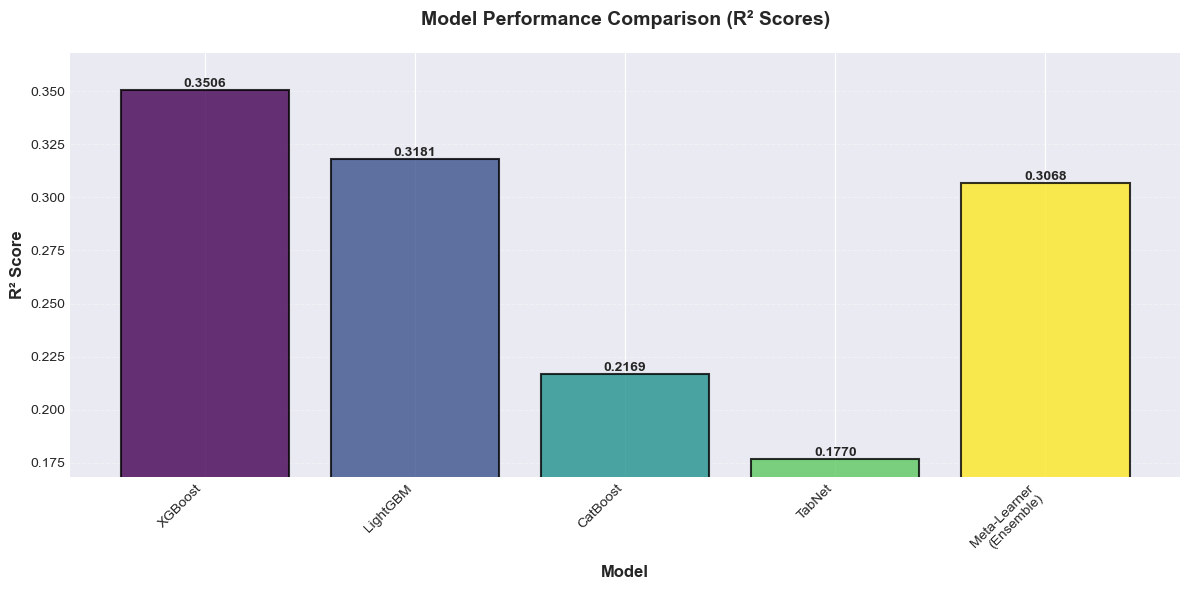

Best individual model: XGBoost (R² = 0.3506)
Ensemble improvement: -0.0438


In [185]:
# Collect R² scores from all models
model_scores = {
    'XGBoost': xgb_r2,
    'LightGBM': lgb_r2,
    'CatBoost': cat_r2
}

if tabnet_model:
    model_scores['TabNet'] = tabnet_r2
if text_model:
    model_scores['TF-IDF+Ridge'] = text_r2
model_scores['Meta-Learner\n(Ensemble)'] = meta_r2

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 6))
models = list(model_scores.keys())
scores = list(model_scores.values())
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
bars = ax.bar(models, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (R² Scores)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([min(scores) * 0.95, max(scores) * 1.05])
ax.grid(axis='y', alpha=0.3, linestyle='--')
# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find best individual model
meta_key = 'Meta-Learner\n(Ensemble)'
best_individual = max([(k, v) for k, v in model_scores.items() if k != meta_key], key=lambda x: x[1])
best_individual_score = best_individual[1]
print(f"Best individual model: {best_individual[0]} (R² = {best_individual_score:.4f})")
print(f"Ensemble improvement: {meta_r2 - best_individual_score:.4f}")

### 2. Ensemble Model Weights


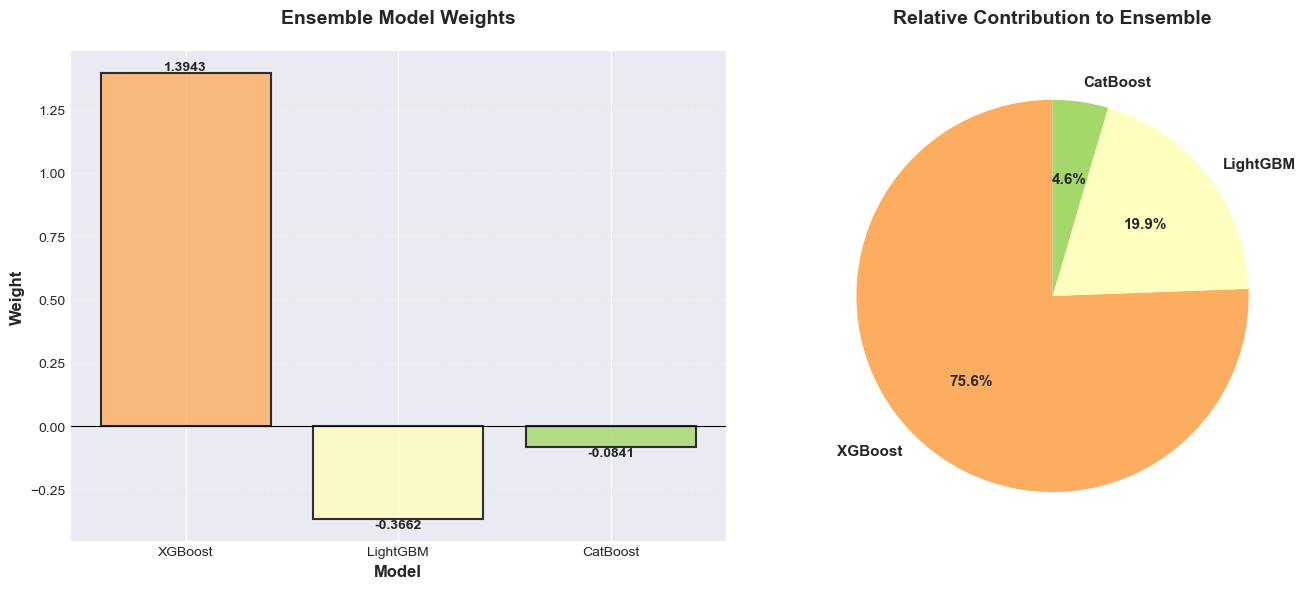

Intercept: 9.60


In [187]:
# Show ensemble weights
model_names = ['XGBoost', 'LightGBM', 'CatBoost']
if tabnet_model:
    model_names.append('TabNet')
if text_model:
    model_names.append('TF-IDF')
weights = meta_model.coef_
model_names = model_names[:len(weights)]  # Trim to match weights length

# Bar plot of weights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(weights)))
bars = ax1.bar(model_names, weights, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Weight', fontsize=12, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_title('Ensemble Model Weights', fontsize=14, fontweight='bold', pad=20)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
# Add value labels
for bar, weight in zip(bars, weights):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{weight:.4f}',
            ha='center', va='bottom' if height > 0 else 'top', fontweight='bold', fontsize=10)

# Pie chart of absolute weights
abs_weights = np.abs(weights)
abs_weights = abs_weights / abs_weights.sum()  # Normalize
ax2.pie(abs_weights, labels=model_names, autopct='%1.1f%%', startangle=90,
        colors=colors, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Relative Contribution to Ensemble', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print(f"Intercept: {meta_model.intercept_:.2f}")

### 3. Distribution of Predicted Points


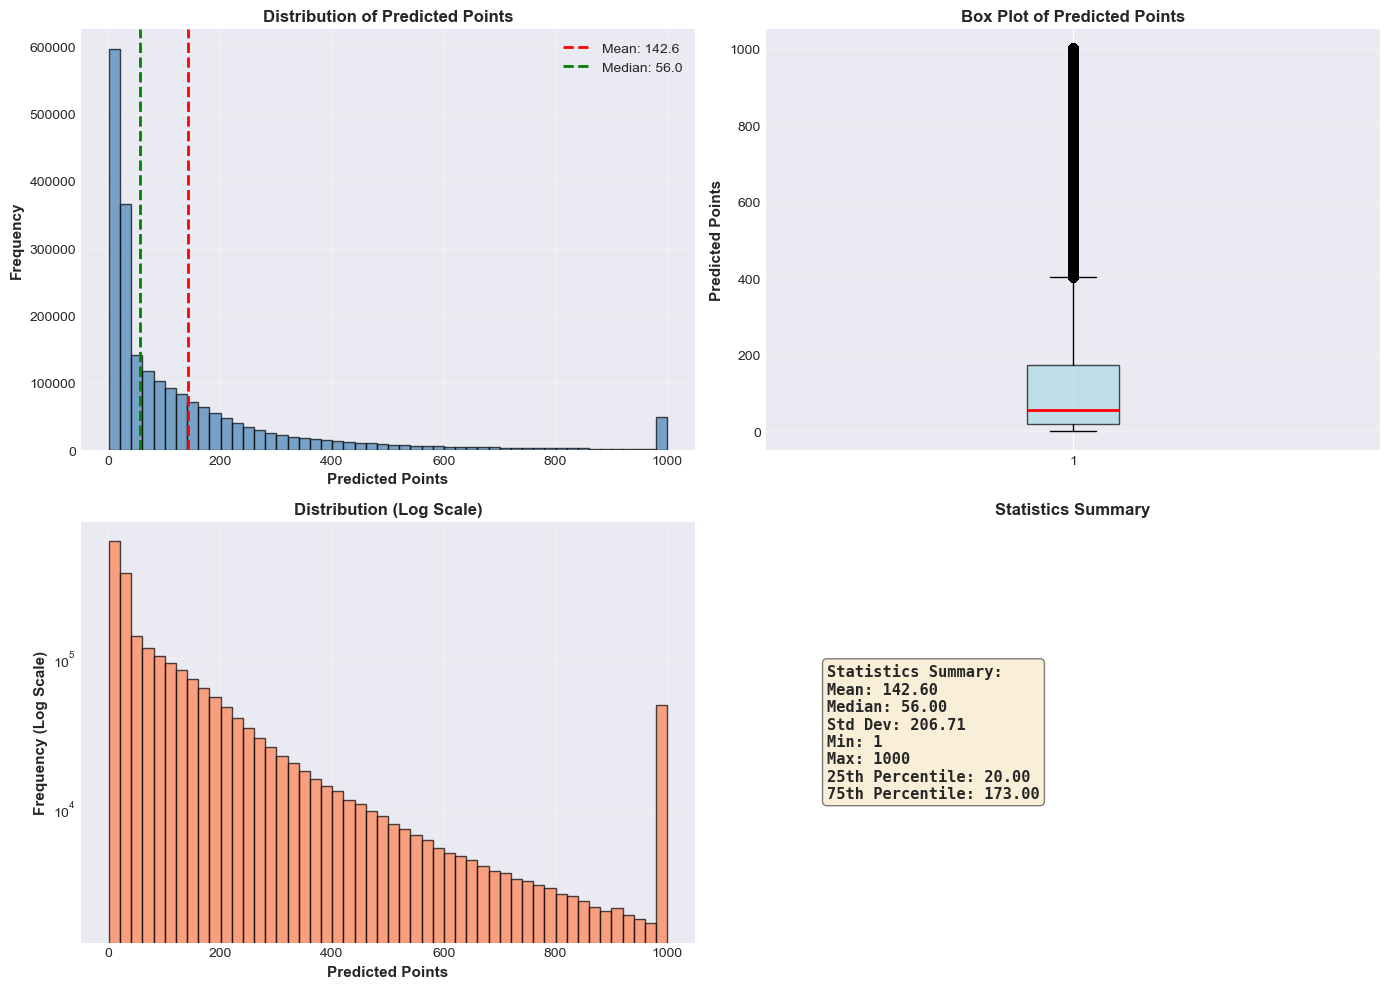

In [188]:
# Distribution of predicted points
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df['calculated_points'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Predicted Points', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribution of Predicted Points', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df['calculated_points'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["calculated_points"].mean():.1f}')
axes[0, 0].axvline(df['calculated_points'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["calculated_points"].median():.1f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot
axes[0, 1].boxplot(df['calculated_points'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_ylabel('Predicted Points', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Box Plot of Predicted Points', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Log scale histogram (to see distribution better)
axes[1, 0].hist(df['calculated_points'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Predicted Points', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency (Log Scale)', fontsize=11, fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Statistics summary
stats_text = f"""Statistics Summary:
Mean: {df['calculated_points'].mean():.2f}
Median: {df['calculated_points'].median():.2f}
Std Dev: {df['calculated_points'].std():.2f}
Min: {df['calculated_points'].min()}
Max: {df['calculated_points'].max()}
25th Percentile: {df['calculated_points'].quantile(0.25):.2f}
75th Percentile: {df['calculated_points'].quantile(0.75):.2f}"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, fontweight='bold',
                verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')
axes[1, 1].set_title('Statistics Summary', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Points by Achievement Rarity


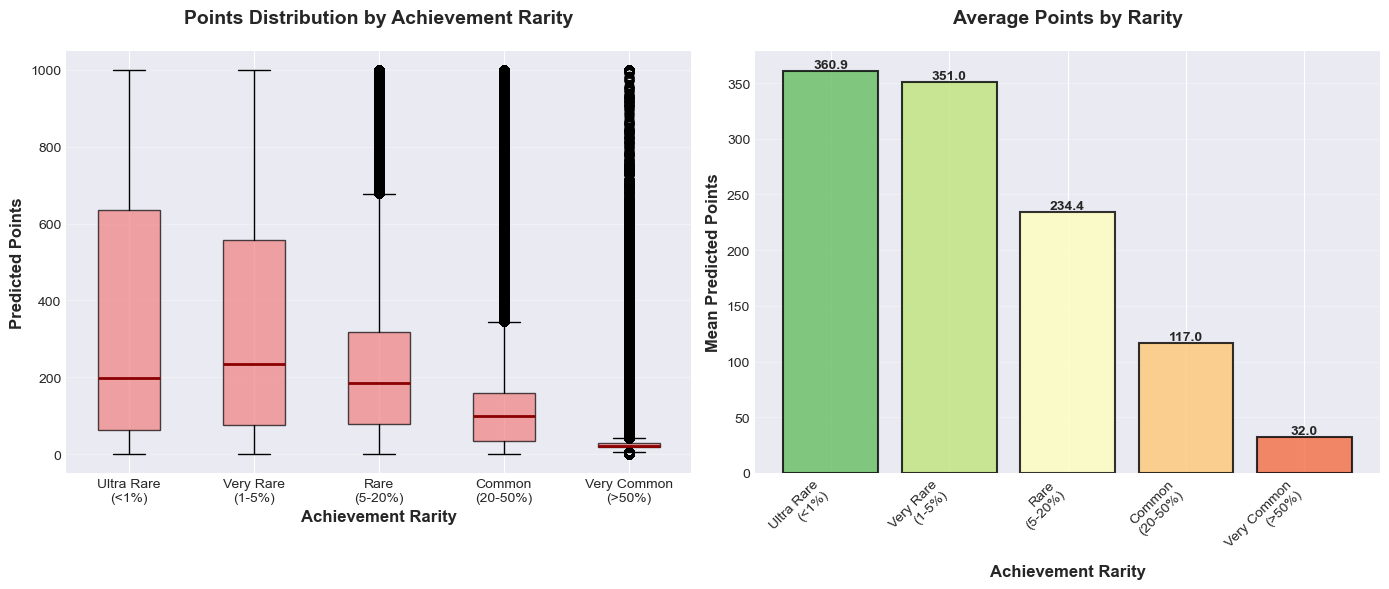

In [189]:
# Points by rarity
df['rarity_bucket'] = pd.cut(df['global_percentage'], 
                              bins=[0, 1, 5, 20, 50, 100], 
                              labels=['Ultra Rare\n(<1%)', 'Very Rare\n(1-5%)', 'Rare\n(5-20%)', 
                                     'Common\n(20-50%)', 'Very Common\n(>50%)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot by rarity
rarity_order = ['Ultra Rare\n(<1%)', 'Very Rare\n(1-5%)', 'Rare\n(5-20%)', 
                'Common\n(20-50%)', 'Very Common\n(>50%)']
data_by_rarity = [df[df['rarity_bucket'] == r]['calculated_points'].values for r in rarity_order]

bp = axes[0].boxplot(data_by_rarity, labels=rarity_order, patch_artist=True, 
                     boxprops=dict(facecolor='lightcoral', alpha=0.7),
                     medianprops=dict(color='darkred', linewidth=2))
axes[0].set_ylabel('Predicted Points', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Achievement Rarity', fontsize=12, fontweight='bold')
axes[0].set_title('Points Distribution by Achievement Rarity', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='y', alpha=0.3)

# Bar plot of mean points by rarity
rarity_means = df.groupby('rarity_bucket')['calculated_points'].mean().reindex(rarity_order)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(rarity_means)))
bars = axes[1].bar(range(len(rarity_means)), rarity_means.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(rarity_means)))
axes[1].set_xticklabels(rarity_means.index, rotation=45, ha='right')
axes[1].set_ylabel('Mean Predicted Points', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Achievement Rarity', fontsize=12, fontweight='bold')
axes[1].set_title('Average Points by Rarity', fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3)
# Add value labels
for bar, mean_val in zip(bars, rarity_means.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{mean_val:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 5. Points by Game Popularity


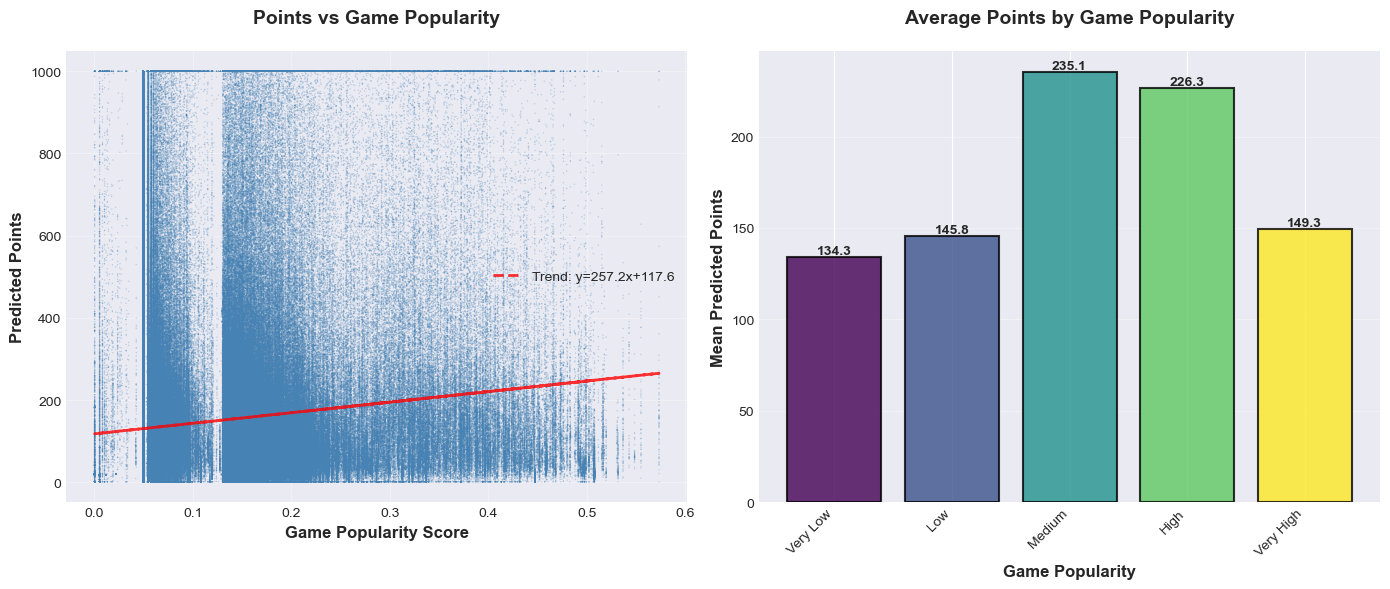

In [190]:
# Points by popularity
df['popularity_bucket'] = pd.cut(df['popularity_score'], bins=5, 
                                  labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: Popularity vs Points
axes[0].scatter(df['popularity_score'], df['calculated_points'], 
                alpha=0.3, s=1, color='steelblue', edgecolors='none')
axes[0].set_xlabel('Game Popularity Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Points', fontsize=12, fontweight='bold')
axes[0].set_title('Points vs Game Popularity', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(alpha=0.3)
# Add trend line
z = np.polyfit(df['popularity_score'], df['calculated_points'], 1)
p = np.poly1d(z)
axes[0].plot(df['popularity_score'], p(df['popularity_score']), 
            "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.1f}x+{z[1]:.1f}')
axes[0].legend()

# Bar plot by popularity bucket
pop_means = df.groupby('popularity_bucket')['calculated_points'].mean()
colors = plt.cm.viridis(np.linspace(0, 1, len(pop_means)))
bars = axes[1].bar(range(len(pop_means)), pop_means.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(pop_means)))
axes[1].set_xticklabels(pop_means.index, rotation=45, ha='right')
axes[1].set_ylabel('Mean Predicted Points', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Game Popularity', fontsize=12, fontweight='bold')
axes[1].set_title('Average Points by Game Popularity', fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3)
# Add value labels
for bar, mean_val in zip(bars, pop_means.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{mean_val:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

### 6. Points by Game Time and Price


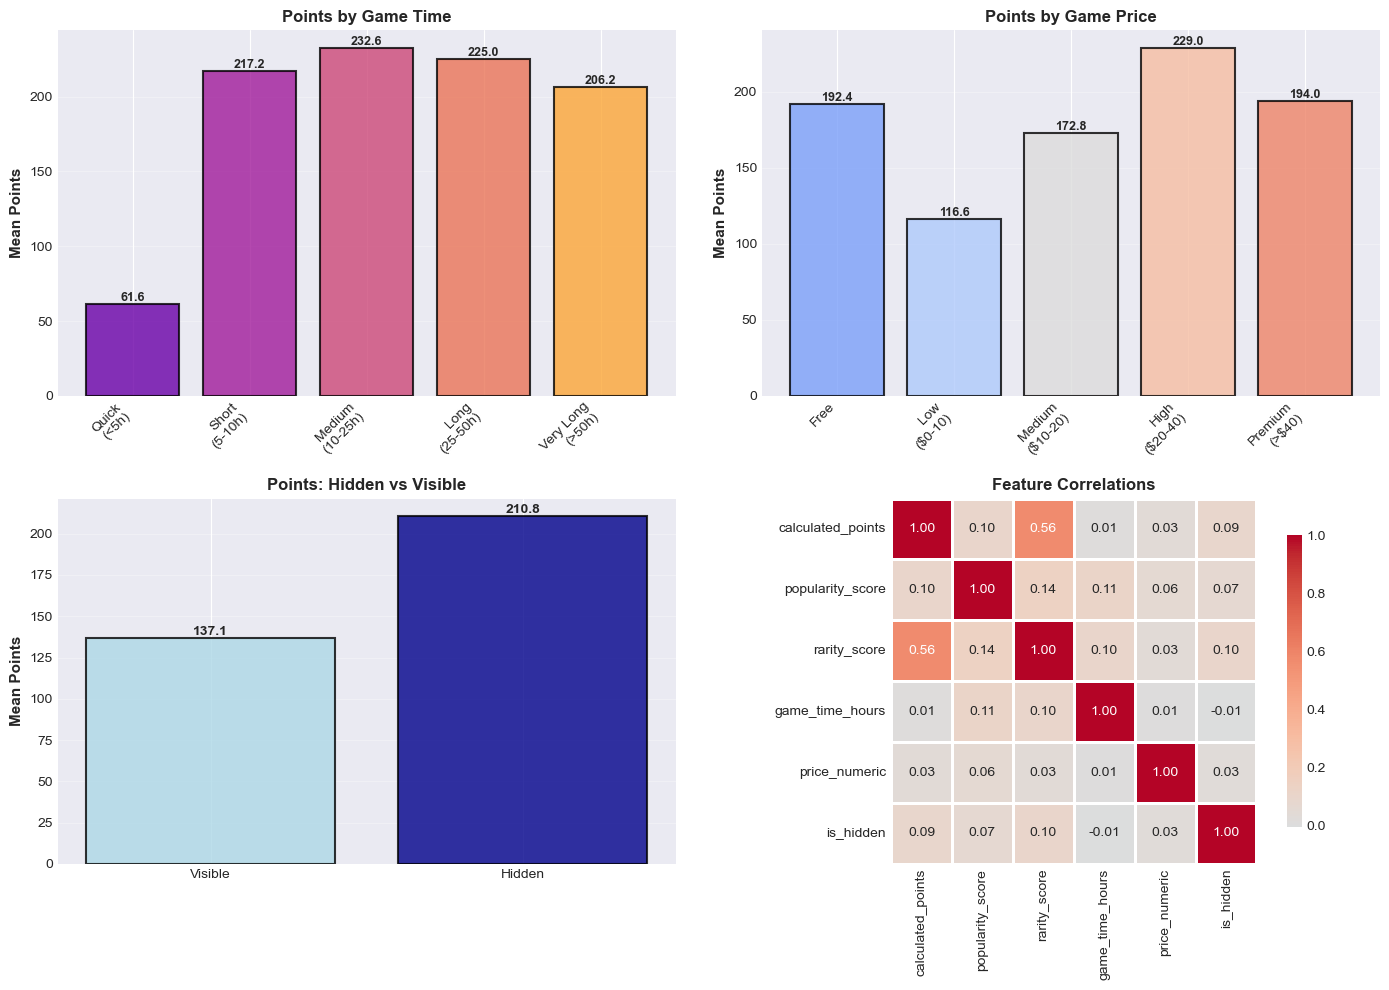

In [191]:
# Points by game time and price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time buckets
df['time_bucket'] = pd.cut(df['game_time_hours'], 
                           bins=[0, 5, 10, 25, 50, 200], 
                           labels=['Quick\n(<5h)', 'Short\n(5-10h)', 'Medium\n(10-25h)', 
                                  'Long\n(25-50h)', 'Very Long\n(>50h)'])

time_means = df.groupby('time_bucket')['calculated_points'].mean()
colors1 = plt.cm.plasma(np.linspace(0.2, 0.8, len(time_means)))
bars1 = axes[0, 0].bar(range(len(time_means)), time_means.values, color=colors1, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0, 0].set_xticks(range(len(time_means)))
axes[0, 0].set_xticklabels(time_means.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Mean Points', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Points by Game Time', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, time_means.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
df['price_bucket'] = pd.cut(df['price_numeric'].fillna(0), 
                            bins=[-1, 0, 10, 20, 40, 1000], 
                            labels=['Free', 'Low\n($0-10)', 'Medium\n($10-20)', 
                                   'High\n($20-40)', 'Premium\n(>$40)'])
price_means = df.groupby('price_bucket')['calculated_points'].mean()
colors2 = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(price_means)))
bars2 = axes[0, 1].bar(range(len(price_means)), price_means.values, color=colors2, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0, 1].set_xticks(range(len(price_means)))
axes[0, 1].set_xticklabels(price_means.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Mean Points', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Points by Game Price', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, price_means.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Hidden vs Visible achievements
hidden_means = df.groupby('is_hidden')['calculated_points'].mean()
hidden_labels = ['Visible', 'Hidden']
colors3 = ['lightblue', 'darkblue']
bars3 = axes[1, 0].bar(hidden_labels, hidden_means.values, color=colors3, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Mean Points', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Points: Hidden vs Visible', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, hidden_means.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Correlation heatmap of key features
corr_features = ['calculated_points', 'popularity_score', 'rarity_score', 
                 'game_time_hours', 'price_numeric', 'is_hidden']
corr_data = df[corr_features].corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Prediction vs Actual (if available)


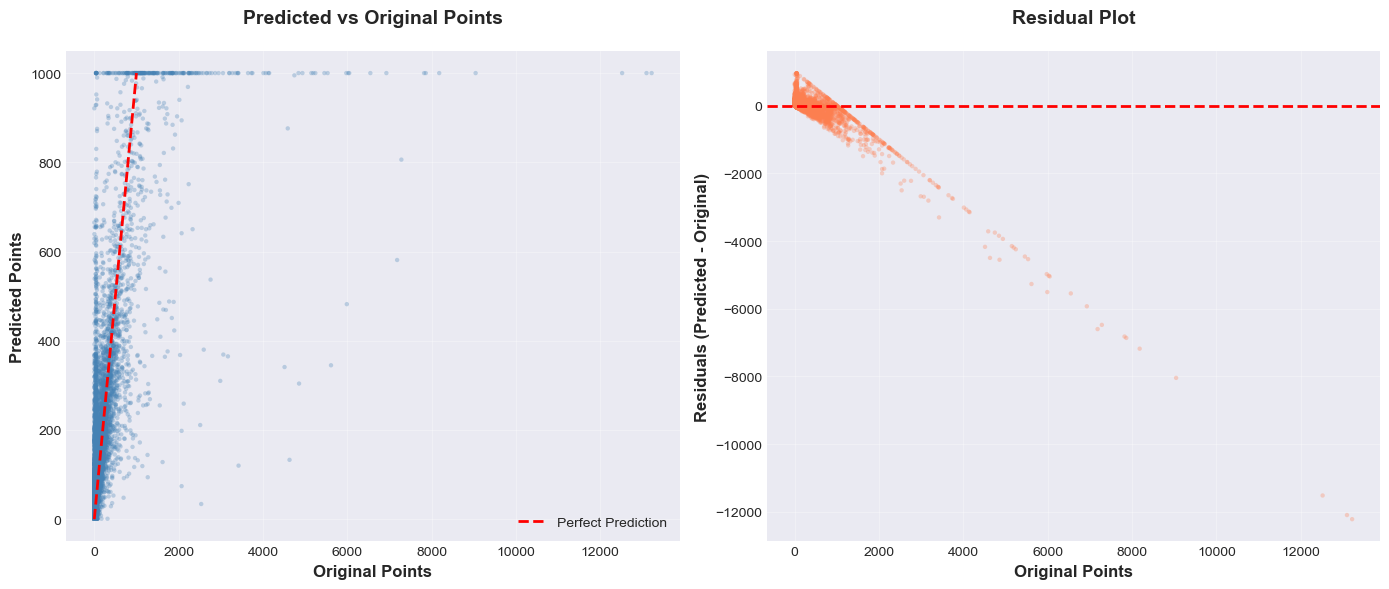

Mean Absolute Error: 104.96
RMSE: 403.77


In [177]:
# Compare predicted vs original points (if we have original points)
if 'current_points' in df.columns and df['current_points'].notna().sum() > 1000:
    # Sample for visualization (too many points for scatter)
    sample_size = min(10000, len(df))
    sample_df = df.sample(n=sample_size, random_state=42)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Scatter plot
    axes[0].scatter(sample_df['current_points'], sample_df['calculated_points'], 
                   alpha=0.3, s=10, color='steelblue', edgecolors='none')
    axes[0].plot([0, 1000], [0, 1000], 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Original Points', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Predicted Points', fontsize=12, fontweight='bold')
    axes[0].set_title('Predicted vs Original Points', fontsize=14, fontweight='bold', pad=20)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Residual plot
    residuals = sample_df['calculated_points'] - sample_df['current_points']
    axes[1].scatter(sample_df['current_points'], residuals, 
                   alpha=0.3, s=10, color='coral', edgecolors='none')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Original Points', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Residuals (Predicted - Original)', fontsize=12, fontweight='bold')
    axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold', pad=20)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Mean Absolute Error: {np.abs(residuals).mean():.2f}")
    print(f"RMSE: {np.sqrt((residuals**2).mean()):.2f}")
else:
    print("Not enough original points data for comparison")

### 8. Feature Importance (Top Features)


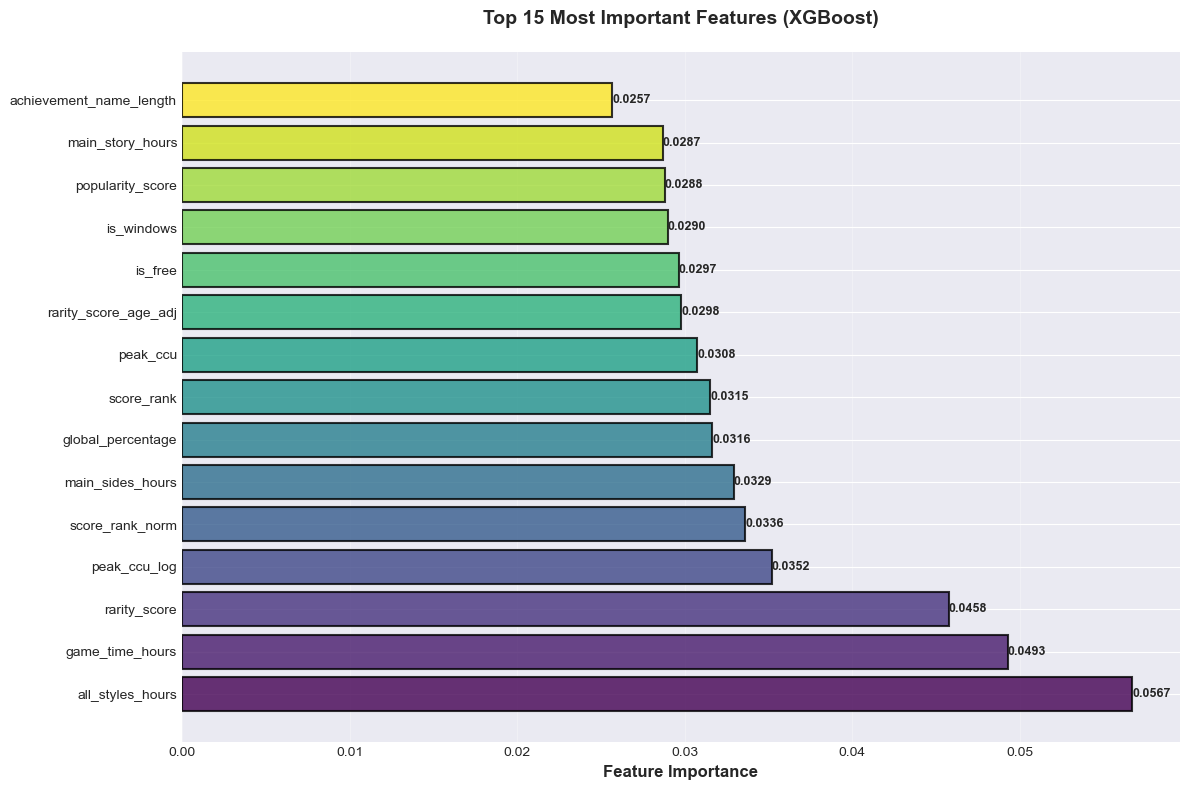

Top 5 Most Important Features:
all_styles_hours: 0.0567
game_time_hours: 0.0493
rarity_score: 0.0458
peak_ccu_log: 0.0352
score_rank_norm: 0.0336


In [192]:
# Get feature importance from XGBoost (most interpretable)
feature_importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': available_numeric,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
bars = ax.barh(range(len(feature_importance_df)), feature_importance_df['importance'].values, 
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(feature_importance_df)))
ax.set_yticklabels(feature_importance_df['feature'].values)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Important Features (XGBoost)', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)
# Add value labels
for i, (bar, imp) in enumerate(zip(bars, feature_importance_df['importance'].values)):
    ax.text(imp, bar.get_y() + bar.get_height()/2.,
            f'{imp:.4f}',
            ha='left', va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

### 9. Summary Dashboard


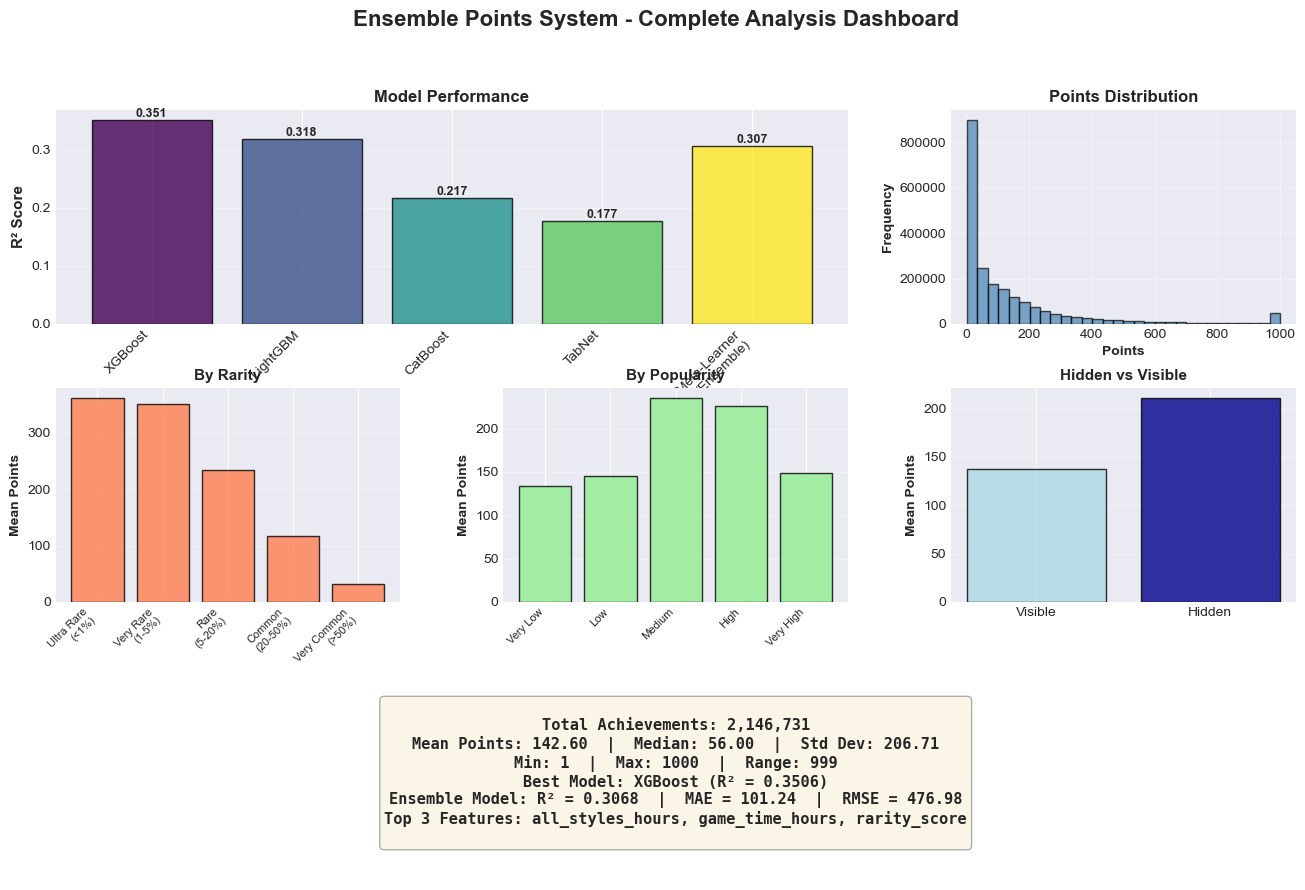

All visualizations complete!


In [193]:
# Create a summary dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Model Performance (top left, spans 2 columns)
ax1 = fig.add_subplot(gs[0, :2])
models_list = list(model_scores.keys())
scores_list = list(model_scores.values())
colors = plt.cm.viridis(np.linspace(0, 1, len(models_list)))
bars = ax1.bar(models_list, scores_list, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('Model Performance', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, scores_list):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Points Distribution (top right)
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(df['calculated_points'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Points', fontsize=10, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax2.set_title('Points Distribution', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

# 3. Points by Rarity (middle left)
ax3 = fig.add_subplot(gs[1, 0])
rarity_means = df.groupby('rarity_bucket')['calculated_points'].mean()
ax3.bar(range(len(rarity_means)), rarity_means.values, color='coral', alpha=0.8, edgecolor='black')
ax3.set_xticks(range(len(rarity_means)))
ax3.set_xticklabels(rarity_means.index, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Mean Points', fontsize=10, fontweight='bold')
ax3.set_title('By Rarity', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Points by Popularity (middle center)
ax4 = fig.add_subplot(gs[1, 1])
pop_means = df.groupby('popularity_bucket')['calculated_points'].mean()
ax4.bar(range(len(pop_means)), pop_means.values, color='lightgreen', alpha=0.8, edgecolor='black')
ax4.set_xticks(range(len(pop_means)))
ax4.set_xticklabels(pop_means.index, rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('Mean Points', fontsize=10, fontweight='bold')
ax4.set_title('By Popularity', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# 5. Hidden vs Visible (middle right)
ax5 = fig.add_subplot(gs[1, 2])
hidden_means = df.groupby('is_hidden')['calculated_points'].mean()
ax5.bar(['Visible', 'Hidden'], hidden_means.values, color=['lightblue', 'darkblue'], 
        alpha=0.8, edgecolor='black')
ax5.set_ylabel('Mean Points', fontsize=10, fontweight='bold')
ax5.set_title('Hidden vs Visible', fontsize=11, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# 6. Statistics Summary (bottom, spans 3 columns)
ax6 = fig.add_subplot(gs[2, :])
stats_summary = f"""
Total Achievements: {len(df):,}
Mean Points: {df['calculated_points'].mean():.2f}  |  Median: {df['calculated_points'].median():.2f}  |  Std Dev: {df['calculated_points'].std():.2f}
Min: {df['calculated_points'].min()}  |  Max: {df['calculated_points'].max()}  |  Range: {df['calculated_points'].max() - df['calculated_points'].min()}
Best Model: {max(model_scores.items(), key=lambda x: x[1] if 'Meta' not in x[0] else 0)[0]} (R² = {max([s for k, s in model_scores.items() if 'Meta' not in k]):.4f})
Ensemble Model: R² = {meta_r2:.4f}  |  MAE = {test_mae:.2f}  |  RMSE = {test_rmse:.2f}
Top 3 Features: {', '.join(feature_importance_df.head(3)['feature'].tolist())}
"""
ax6.text(0.5, 0.5, stats_summary, fontsize=11, fontweight='bold', family='monospace',
        ha='center', va='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax6.axis('off')
plt.suptitle('Ensemble Points System - Complete Analysis Dashboard', 
            fontsize=16, fontweight='bold', y=0.98)
plt.show()
print("All visualizations complete!")

In [194]:
# Save detailed report
report_file = 'ensemble-points-report.csv'
df[['achievement_id', 'game_name', 'achievement_name', 'popularity_score', 
    'rarity_score', 'game_time_hours', 'price_numeric', 'calculated_points', 'global_percentage']].to_csv(
    report_file, index=False
)
print(f"\nDetailed report saved to: {report_file}")


Detailed report saved to: ensemble-points-report.csv


## Step 13: Update Database (Optional)


In [ ]:
# Update database with calculated points
# For future Senior Design Implementation
UPDATE_DB = False  # Set to True to update database
if UPDATE_DB:
    print("\n💾 Updating database...")
    conn = get_db_connection()
    cursor = conn.cursor()
    updated_count = 0
    error_count = 0
    for _, row in df.iterrows():
        try:
            cursor.execute("""
                UPDATE achievements
                SET points = ?
                WHERE id = ?
            """, int(row['calculated_points']), int(row['achievement_id']))
            updated_count += 1
            if updated_count % 10000 == 0:
                conn.commit()
                print(f"Updated {updated_count} achievements...")
        except Exception as e:
            error_count += 1
            if error_count <= 10:
                print(f"Error updating achievement {row['achievement_id']}: {e}")
    conn.commit()
    cursor.close()
    conn.close()
    print(f"\nUpdated {updated_count} achievements")
    if error_count > 0:
        print(f"{error_count} errors encountered")
else:
    print("\nDatabase update skipped (set UPDATE_DB = True to enable)")


Database update skipped (set UPDATE_DB = True to enable)


## Step 14: Save Models (Optional)


In [196]:
SAVE_MODELS = True  # Set to True to save models
if SAVE_MODELS:
    print("\nSaving models...")
    os.makedirs('models', exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Save tree models
    for name, model in tree_models.items():
        filename = f'models/{name}_model_{timestamp}.pkl'
        with open(filename, 'wb') as f:
            pickle.dump(model, f)
        print(f"Saved {name} model")
    
    # Save TabNet
    if tabnet_model:
        filename = f'models/tabnet_model_{timestamp}.pkl'
        with open(filename, 'wb') as f:
            pickle.dump(tabnet_model, f)
        print(f"Saved TabNet model") 
    
    # Save text model
    if text_model:
        filename = f'models/tfidf_model_{timestamp}.pkl'
        with open(filename, 'wb') as f:
            pickle.dump({'model': text_model, 'vectorizer': tfidf}, f)
        print(f"Saved TF-IDF model")
    
    # Save meta-learner
    filename = f'models/meta_model_{timestamp}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(meta_model, f)
    print(f"Saved meta-learner")
    
    # Save metadata
    metadata = {
        'feature_names': available_numeric,
        'timestamp': timestamp
    }
    filename = f'models/metadata_{timestamp}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(metadata, f)
    print(f"Saved metadata")
    print(f"\nAll models saved with timestamp: {timestamp}")
else:
    print("\nModel saving skipped (set SAVE_MODELS = True to enable)")


Saving models...
Saved xgb model
Saved lgb model
Saved cat model
Saved TabNet model
Saved meta-learner
Saved metadata

All models saved with timestamp: 20251206_083900


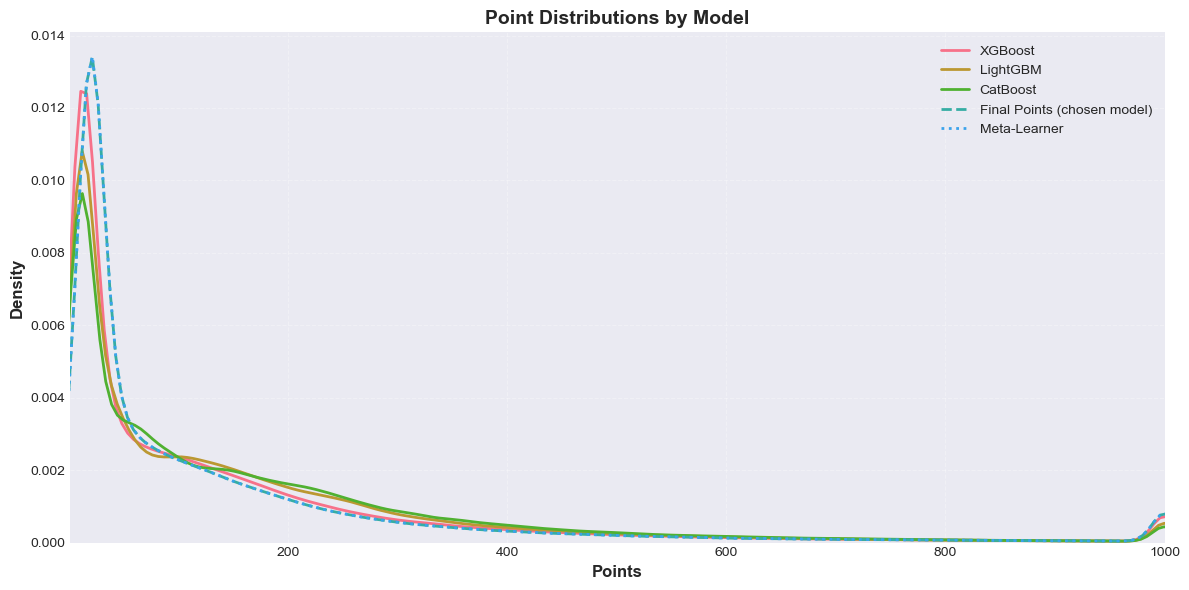

In [181]:
plt.figure(figsize=(12, 6))
sns.set_palette("husl")

xgb_full = tree_models['xgb'].predict(X_numeric)
lgb_full = tree_models['lgb'].predict(X_numeric)
cat_full = tree_models['cat'].predict(X_numeric)
meta_full = None
try:
    full_meta_features = create_meta_features(
        tree_models, None, text_model,
        X_numeric,
        X_tfidf if X_tfidf is not None else None
    )
    meta_full = meta_model.predict(full_meta_features)
except Exception as e:
    print(f"Skipping meta-learner full prediction: {e}")

# Clip to [1, 1000] for fair comparison
def clip_points(arr):
    return np.clip(arr, 1, 1000)

xgb_pts = clip_points(xgb_full)
lgb_pts = clip_points(lgb_full)
cat_pts = clip_points(cat_full)
final_pts = df['calculated_points'].values  # your chosen final points

sns.kdeplot(xgb_pts, label='XGBoost', linewidth=2)
sns.kdeplot(lgb_pts, label='LightGBM', linewidth=2)
sns.kdeplot(cat_pts, label='CatBoost', linewidth=2)
sns.kdeplot(final_pts, label='Final Points (chosen model)', linewidth=2, linestyle='--')

if meta_full is not None:
    sns.kdeplot(clip_points(meta_full), label='Meta-Learner', linewidth=2, linestyle=':')

plt.title("Point Distributions by Model", fontsize=14, fontweight='bold')
plt.xlabel("Points", fontsize=12, fontweight='bold')
plt.ylabel("Density", fontsize=12, fontweight='bold')
plt.xlim(1, 1000)  # focus on the main range
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

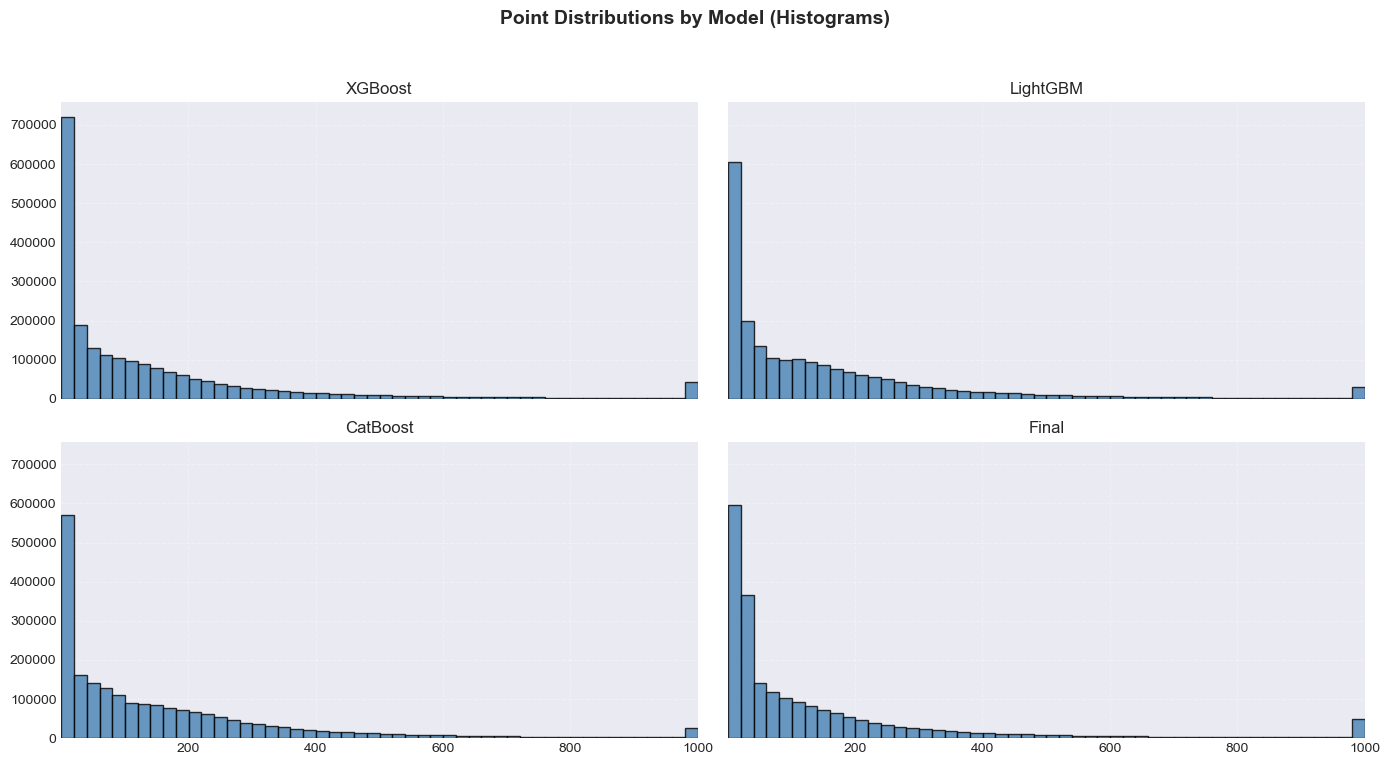

In [197]:
models_for_hist = {
    'XGBoost': xgb_pts,
    'LightGBM': lgb_pts,
    'CatBoost': cat_pts,
    'Final': final_pts
}
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, (name, pts) in zip(axes, models_for_hist.items()):
    ax.hist(pts, bins=50, color='steelblue', alpha=0.8, edgecolor='black')
    ax.set_title(name)
    ax.set_xlim(1, 1000)
    ax.grid(alpha=0.3, linestyle='--')
fig.suptitle("Point Distributions by Model (Histograms)", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [198]:
print("XGB points summary:")
print(np.min(xgb_pts), np.median(xgb_pts), np.mean(xgb_pts), np.max(xgb_pts))

print("\nFinal points summary (df['calculated_points']):")
print(df['calculated_points'].min(),
      df['calculated_points'].median(),
      df['calculated_points'].mean(),
      df['calculated_points'].max())

XGB points summary:
1.0 66.882675 146.49739 1000.0

Final points summary (df['calculated_points']):
1 56.0 142.60478047785213 1000
